# **1- ambiente**

In [1]:
import pandas as pd

# **2- arquivo**

In [2]:
df = pd.read_csv("vendas_brasil_aula1.csv")
df.head()

,Data_Venda,Canal_Venda,UF,Produto,Preco_Unitario,Quantidade,Custo_Unitario,Receita,Lucro
0,2025-04-13,Loja Física,SP,Smartphone,2484.58,3,1872.49,7453.74,1836.27
1,2025-06-29,Loja Física,RJ,Smartwatch,1041.91,1,699.66,1041.91,342.25
2,2025-04-03,E-commerce,RJ,Smartphone,2447.07,1,2077.09,2447.07,369.98
3,2025-01-15,Loja Física,MG,Smartphone,2307.40,1,1797.67,2307.40,509.73
4,2025-04-17,E-commerce,PR,Notebook,3840.18,4,3069.45,15360.72,3082.92


# **3- atividade 1**
1. Quantas linhas e colunas existem no dataset?
2. Quais são os nomes das colunas?
3. Quais são os tipos de dados de cada coluna?

1. 300 linhas, 9 colunas
2. 'Data_Venda', 'Canal_Venda', 'UF', 'Produto', 'Preco_Unitario', 'Quantidade', 'Custo_Unitario', 'Receita', 'Lucro'
3. Data_Venda: object; Canal_Venda: object; UF: object; Produto: object; Preco_unitario: float64; Quantidade: int64; Custo_Unitario: float64; Receita: float64; Lucro: float64.



In [7]:
df.shape

(300, 9)

In [8]:
df.columns

Index(['Data_Venda', 'Canal_Venda', 'UF', 'Produto', 'Preco_Unitario',
       'Quantidade', 'Custo_Unitario', 'Receita', 'Lucro'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Data_Venda      300 non-null    object 
 1   Canal_Venda     293 non-null    object 
 2   UF              294 non-null    object 
 3   Produto         300 non-null    object 
 4   Preco_Unitario  295 non-null    float64
 5   Quantidade      300 non-null    int64  
 6   Custo_Unitario  300 non-null    float64
 7   Receita         300 non-null    float64
 8   Lucro           300 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 21.2+ KB


# **4- atividade 2**
1. Existem valores nulos?
2. Em quais colunas eles aparecem?
3. Existem categorias escritas de formas diferentes para o mesmo canal de venda?

In [3]:
df.isnull().sum()

,0
Data_Venda,0
Canal_Venda,7
UF,6
Produto,0
Preco_Unitario,5
Quantidade,0
Custo_Unitario,0
Receita,0
Lucro,0


In [6]:
df['Canal_Venda'].value_counts()

,count
Canal_Venda,
Loja Física,99
E-commerce,97
Marketplace,42
WhatsApp,37
e-commerce,10
loja fisica,8


1. existem valores null
2. "Data_Venda", "Canal_Venda", "UF", "Produto", "Preco_Unitario", "Quantidade", "Custo_Unitario", "Receita", "Lucro"
3. há duas categorias escrita em dois canais de venda diferentes, "E-commerce", "e-commerce"

# **5- atividade 3**
Calcule os seguintes KPIs:

1. Receita total
2. Lucro total
3. Ticket médio (Receita média por registro)
4. Quantidade total vendida

In [10]:
# Receita total
receita_total = df['Receita'].sum()
print(f"Receita Total: R${receita_total:,.2f}")

Receita Total: R$707,535.36


In [11]:
# Lucro total
lucro_total = df['Lucro'].sum()
print(f"Lucro Total: R${lucro_total:,.2f}")

Lucro Total: R$189,625.88


In [12]:
# Ticket médio (Receita média por registro)
ticket_medio = df['Receita'].mean()
print(f"Ticket Médio: R${ticket_medio:,.2f}")

Ticket Médio: R$2,358.45


In [13]:
# Quantidade total vendida
quantidade_total_vendida = df['Quantidade'].sum()
print(f"Quantidade Total Vendida: {quantidade_total_vendida}")

Quantidade Total Vendida: 502


### Interpretação dos KPIs:

*   **Desempenho Geral:** Mensurar o desemepenho se torna relativo por falta de metas de valores, porém o lucro é maior que a receita geral, então o desempenho é positivo

*   **Receita e Lucro:** O lucro tem uma relação de dependencia com a receita, uma vez que se a receita é maior que o lucro, a empresa está gastanto mais do que arrecada. porém se o lucro sobre a receita também irá subir

# **6- Atividade 4**
1. Qual canal gera mais receita?
2. Qual produto gera mais lucro?
3. Quais UFs concentram maior receita?

Interpretação: a relação de receita por E-commerce está relacionada ao estado com maior densidade populacional SP

In [14]:
# 1. Qual canal gera mais receita?
receita_por_canal = df.groupby('Canal_Venda')['Receita'].sum().sort_values(ascending=False)
print("Receita por Canal de Venda:")
print(receita_por_canal)

Receita por Canal de Venda:
Canal_Venda
E-commerce     220215.54
Loja Física    216644.15
Marketplace    111659.78
WhatsApp        85974.51
e-commerce      29122.47
loja fisica     19001.16
Name: Receita, dtype: float64


In [15]:
# 2. Qual produto gera mais lucro?
lucro_por_produto = df.groupby('Produto')['Lucro'].sum().sort_values(ascending=False)
print("\nLucro por Produto:")
print(lucro_por_produto)


Lucro por Produto:
Produto
Notebook            69818.57
Smartphone          31718.11
Tablet              20936.95
Monitor             18290.52
Smartwatch          17029.45
Teclado Mecânico    12859.48
Fone Bluetooth      11647.92
Mouse Gamer          7324.88
Name: Lucro, dtype: float64


In [16]:
# 3. Quais UFs concentram maior receita?
receita_por_uf = df.groupby('UF')['Receita'].sum().sort_values(ascending=False)
print("\nReceita por UF:")
print(receita_por_uf)


Receita por UF:
UF
SP    133727.80
MG    103438.61
RJ    100284.68
PR     69287.74
SC     63740.20
RS     51020.06
ES     50338.64
BA     46765.01
PE     42895.39
GO     25179.98
Name: Receita, dtype: float64


# 7- atividade 5

Sem necessariamente construir os gráficos ainda, responda:

a) Qual gráfico você usaria para mostrar a evolução da receita ao longo do tempo?
R: grafico de linha

b) Qual gráfico você usaria para comparar a receita entre canais de venda?
R: Grafico de Barras

c) Qual gráfico você usaria para mostrar a distribuição dos preços unitários?
R: histograma

Em seguida, gere ao menos um gráfico com pandas ou matplotlib.

In [20]:
import matplotlib.pyplot as plt


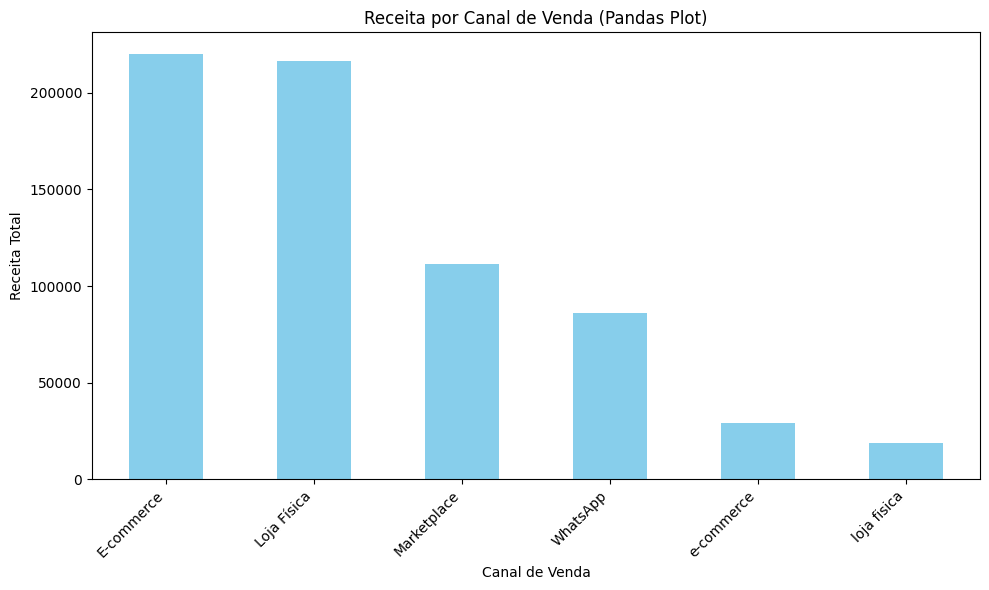

In [22]:

receita_por_canal.plot.bar(figsize=(10, 6), color='skyblue')
plt.title('Receita por Canal de Venda')
plt.xlabel('Canal de Venda')
plt.ylabel('Receita Total')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()